# Fine-tuning DistilBERT — Análisis de Sentimientos Multidominio
**Dataset:** `Drocho/sentiment-unified`  
**Modelo:** `distilbert-base-uncased`  
**Tarea:** Clasificación binaria (0 = negativo, 1 = positivo)


In [ ]:
# Solo ejecutar si no estan instalados, en colab si deberian estar, yo estoy usando mi pc, por ello lo necesitaba
!pip install transformers datasets evaluate scikit-learn matplotlib seaborn -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
import evaluate
import torch
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.12.0+cu130
GPU disponible: True
GPU: NVIDIA GeForce RTX 5070 Ti


## 1. Configuración

In [ ]:
USE_GPU = torch.cuda.is_available()

# Hiperparámetros
MODEL_NAME      = "distilbert-base-uncased"
MAX_LENGTH      = 512 if USE_GPU else 256
BATCH_SIZE      = 16  if USE_GPU else 8
LEARNING_RATE   = 2e-5
NUM_EPOCHS      = 3
WEIGHT_DECAY    = 0.01
WARMUP_RATIO    = 0.1
SEED            = 42

print(f"Dispositivo  : {'GPU' if USE_GPU else 'CPU'}")
print(f"Max tokens   : {MAX_LENGTH}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Épocas       : {NUM_EPOCHS}")


Dispositivo  : GPU
Max tokens   : 512
Batch size   : 16
Learning rate: 2e-05
Épocas       : 3


## 2. Carga del Dataset

In [ ]:
dataset = load_dataset("Drocho/sentiment-unified")
print(dataset)
print("\nEjemplo de entrenamiento:")
print(dataset["train"][0])


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 29196
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 3650
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3650
    })
})

Ejemplo de entrenamiento:
{'text': "i'm confused with the previous reviews. i was excited to go to this place because it was newer and just down the street. but the food experience was not very good. i actually had my husband pick some food up from here. so i didn't go in, however he did say the people were nice and you get free soup while you wait. but the food he brought home was not so good. they did cater to my request to get the seasoned chicken in a pita rather than on the salad. so kudos to them for doing something different for the customer. however, the seasoned chicken was burned, the pitas were burned and chewy, and the hummus was lack luster. no flavor at all. they actually spread the hummus 

In [ ]:
for split in ["train", "validation", "test"]:
    labels = dataset[split]["label"]
    neg = labels.count(0)
    pos = labels.count(1)
    print(f"{split:10s} → total: {len(labels):5d} | neg: {neg:5d} | pos: {pos:5d}")


train      → total: 29196 | neg: 14672 | pos: 14524
validation → total:  3650 | neg:  1850 | pos:  1800
test       → total:  3650 | neg:  1860 | pos:  1790


## 3. Tokenización

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,          # el DataCollator hace el padding dinámico
    )

tokenized = dataset.map(tokenize, batched=True, remove_columns=["text"])
# tokenized.set_format("torch") | da error en colab

print("Columnas disponibles:", tokenized["train"].column_names)
# print("Ejemplo tokenizado (input_ids shape):", tokenized["train"][0]["input_ids"].shape) | da error en colab, el resultado de la ejecución ya sale


Columnas disponibles: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Ejemplo tokenizado (input_ids shape): torch.Size([301])


## 4. Modelo

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1},
)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales    : {total_params:,}")
print(f"Parámetros entrenables: {trainable:,}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parámetros totales    : 66,955,010
Parámetros entrenables: 66,955,010


## 5. Función de métricas

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy" : accuracy_score(labels, preds),
        "f1"       : f1_score(labels, preds, average="binary"),
        "precision": precision_score(labels, preds, average="binary"),
        "recall"   : recall_score(labels, preds, average="binary"),
    }

## 6. Fine-tuning

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir                  = "./distilbert-sentiment",
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    logging_dir                 = "./logs",
    logging_steps               = 50,
    seed                        = SEED,
    report_to                   = "none",
    fp16                        = USE_GPU,   # mixed precision solo en GPU
)

trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = tokenized["train"],
    eval_dataset      = tokenized["validation"],
    processing_class  = tokenizer,
    data_collator     = data_collator,
    compute_metrics   = compute_metrics,
    callbacks         = [EarlyStoppingCallback(early_stopping_patience=2)],
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
train_result = trainer.train()
print("\n Entrenamiento finalizado")
print(f"   Tiempo total : {train_result.metrics['train_runtime']:.1f}s")
print(f"   Loss final   : {train_result.metrics['train_loss']:.4f}")


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.212340,0.256327,0.906575,0.909236,0.872764,0.948889
2,0.119232,0.248335,0.933699,0.932175,0.940611,0.923889
3,0.066310,0.299272,0.932055,0.930765,0.935466,0.926111


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Entrenamiento finalizado
   Tiempo total : 275.0s
   Loss final   : 0.1789


## 7. Curvas de aprendizaje

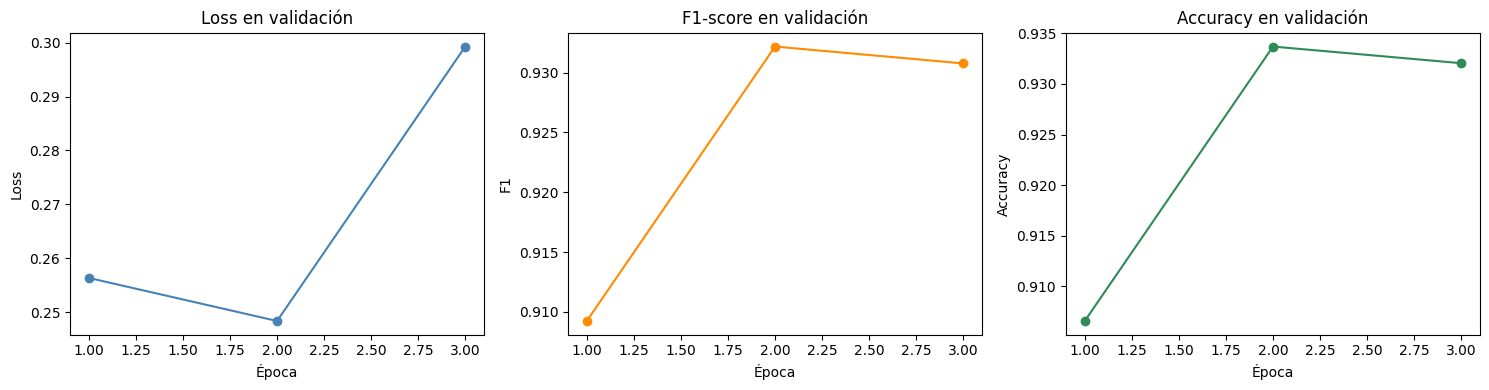

Guardada: curvas_entrenamiento.png


In [ ]:
log_history = trainer.state.log_history

# Separar logs de entrenamiento y evaluación
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

epochs_eval   = [x["epoch"]     for x in eval_logs]
eval_loss     = [x["eval_loss"] for x in eval_logs]
eval_f1       = [x["eval_f1"]   for x in eval_logs]
eval_accuracy = [x["eval_accuracy"] for x in eval_logs]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_eval, eval_loss, marker="o", color="steelblue")
axes[0].set_title("Loss en validación"); axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")

axes[1].plot(epochs_eval, eval_f1, marker="o", color="darkorange")
axes[1].set_title("F1-score en validación"); axes[1].set_xlabel("Época"); axes[1].set_ylabel("F1")

axes[2].plot(epochs_eval, eval_accuracy, marker="o", color="seagreen")
axes[2].set_title("Accuracy en validación"); axes[2].set_xlabel("Época"); axes[2].set_ylabel("Accuracy")

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: curvas_entrenamiento.png")


## 8. Evaluación en conjunto de prueba

In [ ]:
test_results = trainer.evaluate(tokenized["test"])
print("\n📊 Resultados en test:")
for k, v in test_results.items():
    if k.startswith("eval_"):
        print(f"  {k[5:]:12s}: {v:.4f}")


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.066310,0.262439,3,0.928493,0.926334,0.936110,0.916760



📊 Resultados en test:
  loss        : 0.2624
  accuracy    : 0.9285
  f1          : 0.9263
  precision   : 0.9361
  recall      : 0.9168


In [ ]:
preds_output = trainer.predict(tokenized["test"])
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print("\n📋 Reporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=["Negativo", "Positivo"]))



📋 Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.92      0.94      0.93      1860
    Positivo       0.94      0.92      0.93      1790

    accuracy                           0.93      3650
   macro avg       0.93      0.93      0.93      3650
weighted avg       0.93      0.93      0.93      3650



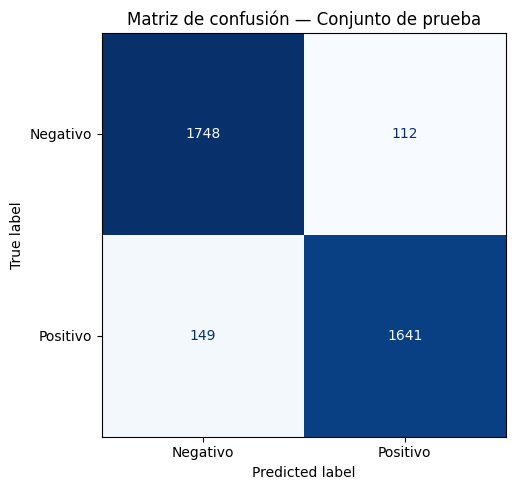

Guardada: matriz_confusion.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo", "Positivo"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusión — Conjunto de prueba")
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: matriz_confusion.png")


## 9. Línea base — TF-IDF + Regresión Logística

In [ ]:
train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]
test_texts  = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
X_train = tfidf.fit_transform(train_texts)
X_test  = tfidf.transform(test_texts)

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
lr.fit(X_train, train_labels)
baseline_preds = lr.predict(X_test)

print("📊 Baseline TF-IDF + Regresión Logística:")
print(classification_report(test_labels, baseline_preds, target_names=["Negativo", "Positivo"]))


📊 Baseline TF-IDF + Regresión Logística:
              precision    recall  f1-score   support

    Negativo       0.88      0.89      0.89      1860
    Positivo       0.89      0.87      0.88      1790

    accuracy                           0.88      3650
   macro avg       0.88      0.88      0.88      3650
weighted avg       0.88      0.88      0.88      3650



## 10. Comparación DistilBERT vs Baseline

Métrica        DistilBERT    TF-IDF+LR     Mejora
--------------------------------------------------
Accuracy           0.9285       0.8822     +4.63%
F1-score           0.9263       0.8790     +4.73%
Precision          0.9361       0.8855     +5.06%
Recall             0.9168       0.8726     +4.41%


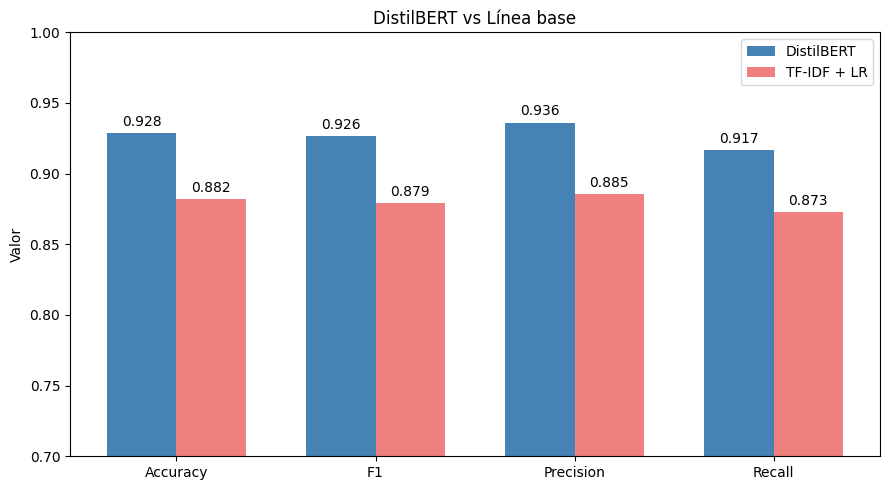

Guardada: comparacion_modelos.png


In [ ]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

# DistilBERT
db_acc  = accuracy_score(y_true, y_pred)
db_f1   = f1_score(y_true, y_pred)
db_prec = precision_score(y_true, y_pred)
db_rec  = recall_score(y_true, y_pred)

# Baseline
bl_acc  = accuracy_score(test_labels, baseline_preds)
bl_f1   = f1_score(test_labels, baseline_preds)
bl_prec = precision_score(test_labels, baseline_preds)
bl_rec  = recall_score(test_labels, baseline_preds)

print(f"{'Métrica':<12} {'DistilBERT':>12} {'TF-IDF+LR':>12} {'Mejora':>10}")
print("-" * 50)
for metric, db, bl in [
    ("Accuracy",  db_acc,  bl_acc),
    ("F1-score",  db_f1,   bl_f1),
    ("Precision", db_prec, bl_prec),
    ("Recall",    db_rec,  bl_rec),
]:
    print(f"{metric:<12} {db:>12.4f} {bl:>12.4f} {(db-bl)*100:>+9.2f}%")

# Gráfico comparativo
metrics  = ["Accuracy", "F1", "Precision", "Recall"]
db_vals  = [db_acc, db_f1, db_prec, db_rec]
bl_vals  = [bl_acc, bl_f1, bl_prec, bl_rec]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, db_vals, width, label="DistilBERT", color="steelblue")
bars2 = ax.bar(x + width/2, bl_vals, width, label="TF-IDF + LR", color="lightcoral")
ax.set_ylim(0.7, 1.0)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("Valor"); ax.set_title("DistilBERT vs Línea base")
ax.legend(); ax.bar_label(bars1, fmt="%.3f", padding=3); ax.bar_label(bars2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: comparacion_modelos.png")


## 11. Análisis de errores

In [ ]:
test_texts_list = dataset["test"]["text"]

errors = [
    {"text": test_texts_list[i], "true": y_true[i], "pred": y_pred[i]}
    for i in range(len(y_true))
    if y_true[i] != y_pred[i]
]

label_map = {0: "Negativo", 1: "Positivo"}
print(f"Total de errores: {len(errors)} / {len(y_true)} ({len(errors)/len(y_true)*100:.1f}%)")
print("\n--- Ejemplos de Falsos Positivos (predijo Positivo, era Negativo) ---")
fp = [e for e in errors if e["true"] == 0 and e["pred"] == 1]
for e in fp[:5]:
    print(f"  Texto: {e['text'][:120]}...")
    print()

print("--- Ejemplos de Falsos Negativos (predijo Negativo, era Positivo) ---")
fn = [e for e in errors if e["true"] == 1 and e["pred"] == 0]
for e in fn[:5]:
    print(f"  Texto: {e['text'][:120]}...")
    print()


Total de errores: 261 / 3650 (7.2%)

--- Ejemplos de Falsos Positivos (predijo Positivo, era Negativo) ---
  Texto: 'helen of troy' follows the story of helen and the outbreak of the trojan war. this is more of a love story between hele...

  Texto: if you're at the hospital and want something other than hospital food, this place may be the ticket. right across the st...

  Texto: so we stayed here after deciding to come to vegas on a whim. i don't have much to say about it considering my boyfriend ...

  Texto: for fashioning an engrossing entertainment out of an almost sure-fire prescription for a critical and commercial disaste...

  Texto: beyond its limit to sustain a laugh...

--- Ejemplos de Falsos Negativos (predijo Negativo, era Positivo) ---
  Texto: i found this book extremely helpful and useful for helping me find a graduate school for my mba. i was a little disappoi...

  Texto: i can't believe people are looking for a plot in this film. this is laural and hardy. lighten u

## 12. Guardar modelo (opcional)

In [ ]:
# Guardar localmente
trainer.save_model("./distilbert-sentiment-final")
tokenizer.save_pretrained("./distilbert-sentiment-final")
print("Modelo guardado en ./distilbert-sentiment-final")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en ./distilbert-sentiment-final


## 13. Resumen para el informe

In [ ]:
print("=" * 55)
print("  RESUMEN DE RESULTADOS — ENTREGABLE 2")
print("=" * 55)
print(f"  Modelo        : {MODEL_NAME}")
print(f"  Dataset       : Drocho/sentiment-unified")
print(f"  Max tokens    : {MAX_LENGTH}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Épocas        : {NUM_EPOCHS}")
print("-" * 55)
print(f"  {'Métrica':<12} {'DistilBERT':>12} {'Baseline':>12}")
print(f"  {'-'*38}")
for metric, db, bl in [
    ("Accuracy",  db_acc,  bl_acc),
    ("F1-score",  db_f1,   bl_f1),
    ("Precision", db_prec, bl_prec),
    ("Recall",    db_rec,  bl_rec),
]:
    print(f"  {metric:<12} {db:>12.4f} {bl:>12.4f}")
print("=" * 55)
print("Imágenes generadas:")
print("  - curvas_entrenamiento.png")
print("  - matriz_confusion.png")
print("  - comparacion_modelos.png")


  RESUMEN DE RESULTADOS — ENTREGABLE 2
  Modelo        : distilbert-base-uncased
  Dataset       : Drocho/sentiment-unified
  Max tokens    : 512
  Batch size    : 16
  Learning rate : 2e-05
  Épocas        : 3
-------------------------------------------------------
  Métrica        DistilBERT     Baseline
  --------------------------------------
  Accuracy           0.9285       0.8822
  F1-score           0.9263       0.8790
  Precision          0.9361       0.8855
  Recall             0.9168       0.8726
Imágenes generadas:
  - curvas_entrenamiento.png
  - matriz_confusion.png
  - comparacion_modelos.png
